# Penalties Visualization

Creating a professional penalties visualization showing awarded vs given away penalties, with split bars for scored/missed.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patheffects as path_effects

# Load data
shots_df_path = Path('../data/raw/mt1cfl_2526/raw_by_match')
all_shots = []

for match_dir in shots_df_path.iterdir():
    if match_dir.is_dir():
        shots_file = match_dir / 'match_shots.csv'
        if shots_file.exists():
            try:
                match_id = match_dir.name
                df = pd.read_csv(shots_file)
                if len(df) > 0:
                    df['match_id'] = match_id
                    all_shots.append(df)
            except:
                continue

shots_df = pd.concat(all_shots, ignore_index=True)
matches_df = pd.read_csv('../data/processed/matches_metadata.csv')
matches_df['match_id'] = matches_df['match_id'].astype(str)
teams_metadata = pd.read_csv('../data/processed/teams_metadata.csv')

print(f"✅ Data loaded: {len(shots_df)} shots from {matches_df['match_id'].nunique()} matches")

✅ Data loaded: 2022 shots from 95 matches


In [69]:
# Filter for ALL penalty kicks (not just goals)
penalty_shots = shots_df[shots_df['situation'] == 'penalty'].copy()

print(f"Total penalty kicks taken: {len(penalty_shots)}")
print(f"Penalty goals: {len(penalty_shots[penalty_shots['shotType'] == 'goal'])}")
print(f"Conversion rate: {len(penalty_shots[penalty_shots['shotType'] == 'goal']) / len(penalty_shots) * 100:.1f}%\n")

# Merge with match data to get team names
penalty_shots_with_teams = penalty_shots.merge(
    matches_df[['match_id', 'homeTeam_name', 'awayTeam_name']], 
    on='match_id', 
    how='left'
)

# Determine team that took the penalty
penalty_shots_with_teams['taking_team'] = penalty_shots_with_teams.apply(
    lambda row: row['homeTeam_name'] if row['isHome'] else row['awayTeam_name'], 
    axis=1
)

# Determine team that gave away the penalty
penalty_shots_with_teams['giving_team'] = penalty_shots_with_teams.apply(
    lambda row: row['awayTeam_name'] if row['isHome'] else row['homeTeam_name'], 
    axis=1
)

# Count penalties awarded to each team
penalties_awarded = penalty_shots_with_teams['taking_team'].value_counts().sort_index()

# Count penalties given away by each team
penalties_given = penalty_shots_with_teams['giving_team'].value_counts().sort_index()

# Count how many were scored by each team
penalty_goals_by_team = penalty_shots_with_teams[penalty_shots_with_teams['shotType'] == 'goal'].groupby('taking_team').size()

# Create full comparison DataFrame
penalty_full_comparison = pd.DataFrame({
    'Penalties_Awarded': penalties_awarded,
    'Penalties_Scored': penalty_goals_by_team,
    'Penalties_Given_Away': penalties_given
}).fillna(0).astype(int)

penalty_full_comparison['Penalties_Missed'] = penalty_full_comparison['Penalties_Awarded'] - penalty_full_comparison['Penalties_Scored']
penalty_full_comparison['Conversion_%'] = (penalty_full_comparison['Penalties_Scored'] / penalty_full_comparison['Penalties_Awarded'] * 100).round(1)

# Calculate penalties given away broken down by outcome (goal vs saved)
penalties_conceded_goals = penalty_shots_with_teams[penalty_shots_with_teams['shotType'] == 'goal'].groupby('giving_team').size()
penalties_conceded_saved = penalty_shots_with_teams[penalty_shots_with_teams['shotType'] != 'goal'].groupby('giving_team').size()

# Add to the comparison dataframe
penalty_full_comparison['Penalties_Conceded_Goals'] = penalties_conceded_goals
penalty_full_comparison['Penalties_Conceded_Saved'] = penalties_conceded_saved
penalty_full_comparison = penalty_full_comparison.fillna(0).astype(int)

print("\nFULL PENALTY STATISTICS BY TEAM")
print("="*100)
display(penalty_full_comparison.sort_values('Penalties_Awarded', ascending=False))

Total penalty kicks taken: 27
Penalty goals: 24
Conversion rate: 88.9%


FULL PENALTY STATISTICS BY TEAM


,Penalties_Awarded,Penalties_Scored,Penalties_Given_Away,Penalties_Missed,Conversion_%,Penalties_Conceded_Goals,Penalties_Conceded_Saved
Mladost DG,7,6,2,1,85,2,0
FK Dečić Tuzi,4,4,3,0,100,3,0
FK Jezero,3,3,0,0,100,0,0
FK Budućnost Podgorica,3,2,4,1,66,4,0
FK Jedinstvo Bijelo Polje,2,2,0,0,100,0,0
FK Bokelj Kotor,2,2,6,0,100,6,0
FK Sutjeska Nikšić,2,2,3,0,100,2,1
FK Mornar Bar,2,1,4,1,50,3,1
FK Arsenal Tivat,1,1,2,0,100,2,0
OFK Petrovac,1,1,3,0,100,2,1


In [70]:
# Merge with teams metadata to get short names and team IDs
penalty_viz_data = penalty_full_comparison.reset_index()
penalty_viz_data.columns = ['Team'] + list(penalty_viz_data.columns[1:])

penalty_viz_data = penalty_viz_data.merge(
    teams_metadata[['team_name', 'short_name', 'team_id']], 
    left_on='Team', 
    right_on='team_name',
    how='left'
)

# Sort by penalties awarded (descending) and take top 10
top_awarded = penalty_viz_data.nlargest(10, 'Penalties_Awarded').copy()
top_awarded = top_awarded.sort_values('Penalties_Awarded', ascending=True)  # For horizontal bars

# Sort by penalties given away (descending) and take top 10
top_given = penalty_viz_data.nlargest(10, 'Penalties_Given_Away').copy()
top_given = top_given.sort_values('Penalties_Given_Away', ascending=True)  # For horizontal bars

print(f"Top 10 teams by penalties awarded: {len(top_awarded)}")
print(f"Top 10 teams by penalties given away: {len(top_given)}")

Top 10 teams by penalties awarded: 10
Top 10 teams by penalties given away: 10


✅ Final penalties post saved to: outputs/final_posts/penalties_post.png


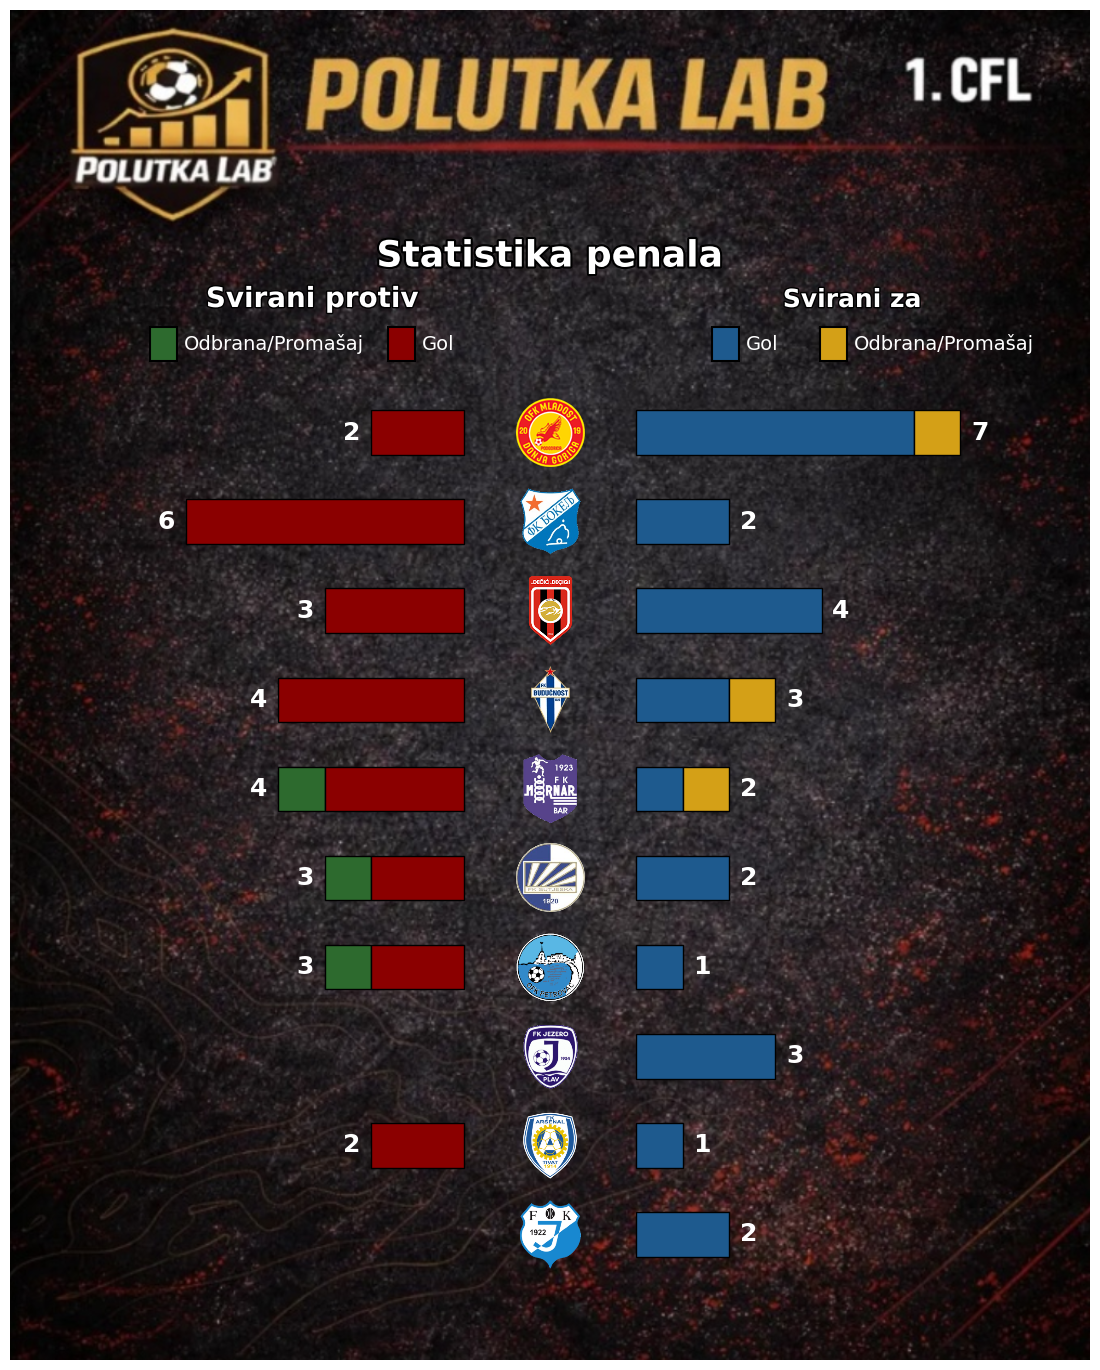

In [85]:
# Create final Instagram 4:5 visualization directly
# Sort teams by total penalties involvement (awarded + given away)
penalty_viz_data['Total_Involved'] = penalty_viz_data['Penalties_Awarded'] + penalty_viz_data['Penalties_Given_Away']
top_teams = penalty_viz_data.nlargest(10, 'Total_Involved').copy()
top_teams = top_teams.sort_values('Total_Involved', ascending=True)  # Bottom to top

# Define darker colors with better contrast
COLOR_AWARDED_SCORED = '#1e5a8e'    # Dark blue for scored
COLOR_AWARDED_MISSED = '#d4a017'    # Gold for missed
COLOR_CONCEDED_GOAL = '#8B0000'     # Dark red for conceded goals
COLOR_CONCEDED_SAVED = '#2d6a2e'    # Dark green for saved

# Load and resize background to Instagram dimensions
INSTAGRAM_SIZE = (1080, 1350)
background_img = Image.open('../outputs/figures/background.png')
if background_img.size != INSTAGRAM_SIZE:
    background_img = background_img.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
background_array = np.array(background_img)

# Create figure with 4:5 aspect ratio (Instagram dimensions)
fig, ax = plt.subplots(figsize=(10.8, 13.5), dpi=100)
ax.axis('off')
ax.set_position([0, 0, 1, 1])

# Display background image
ax.imshow(background_array, aspect='auto', extent=[0, 1, 0, 1], zorder=0)

# Title (adjusted for 4:5 format, positioned in chart area below logo)
title = ax.text(0.5, 0.83, 'Statistika penala', 
        transform=fig.transFigure, fontsize=26, fontweight='bold',
        ha='center', va='top', color='white')
title.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                        path_effects.Normal()])

# Subtitle with legend
legend_y = 0.78
subtitle_left = ax.text(0.28, legend_y, 'Svirani protiv', 
        transform=fig.transFigure, fontsize=20, fontweight='bold',
        ha='center', color='white')
subtitle_left.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                path_effects.Normal()])
subtitle_right = ax.text(0.78, legend_y, 'Svirani za', 
        transform=fig.transFigure, fontsize=18, fontweight='bold',
        ha='center', color='white')
subtitle_right.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                 path_effects.Normal()])

# Color legend boxes - 4 colors total
legend_box_size = 0.025  # Bigger legend boxes
legend_y_boxes = legend_y - 0.04

# LEFT SIDE LEGEND (Primljeni/Conceded) - Green first, then Red
# Dark green box (conceded - saved)
rect_conceded_saved = plt.Rectangle((0.13, legend_y_boxes), legend_box_size, legend_box_size, 
                            facecolor=COLOR_CONCEDED_SAVED, edgecolor='black', linewidth=1.5,
                            transform=fig.transFigure, zorder=10)
fig.add_artist(rect_conceded_saved)
ax.text(0.13 + legend_box_size + 0.006, legend_y_boxes + legend_box_size/2, 'Odbrana/Promašaj', 
        transform=fig.transFigure, fontsize=14, va='center', color='white')

# Dark red box (conceded - goal)
rect_conceded_goal = plt.Rectangle((0.35, legend_y_boxes), legend_box_size, legend_box_size, 
                            facecolor=COLOR_CONCEDED_GOAL, edgecolor='black', linewidth=1.5,
                            transform=fig.transFigure, zorder=10)
fig.add_artist(rect_conceded_goal)
ax.text(0.35 + legend_box_size + 0.006, legend_y_boxes + legend_box_size/2, 'Gol', 
        transform=fig.transFigure, fontsize=14, va='center', color='white')

# RIGHT SIDE LEGEND (Dodijeljeni/Awarded)
# Dark blue box (awarded - scored)
rect_awarded_scored = plt.Rectangle((0.65, legend_y_boxes), legend_box_size, legend_box_size, 
                            facecolor=COLOR_AWARDED_SCORED, edgecolor='black', linewidth=1.5,
                            transform=fig.transFigure, zorder=10)
fig.add_artist(rect_awarded_scored)
ax.text(0.65 + legend_box_size + 0.006, legend_y_boxes + legend_box_size/2, 'Gol', 
        transform=fig.transFigure, fontsize=14, va='center', color='white')

# Gold box (awarded - missed)
rect_awarded_missed = plt.Rectangle((0.75, legend_y_boxes), legend_box_size, legend_box_size, 
                            facecolor=COLOR_AWARDED_MISSED, edgecolor='black', linewidth=1.5,
                            transform=fig.transFigure, zorder=10)
fig.add_artist(rect_awarded_missed)
ax.text(0.75 + legend_box_size + 0.006, legend_y_boxes + legend_box_size/2, 'Odbrana/Promašaj', 
        transform=fig.transFigure, fontsize=14, va='center', color='white')

# Setup chart area (fits in bottom 4/5 of figure, below branding)
chart_top = 0.72
chart_bottom = 0.06
num_teams = len(top_teams)
row_height = (chart_top - chart_bottom) / num_teams

# Find max values for scaling
max_awarded = top_teams['Penalties_Awarded'].max()
max_given = top_teams['Penalties_Given_Away'].max()
max_value = max(max_awarded, max_given)

# Bar width scaling
left_scale = 0.30 / max_value  # Left side spans 30% of figure width
right_scale = 0.30 / max_value  # Right side spans 30% of figure width

# Center position for logos
center_x = 0.5

# Draw bars for each team
for i, (idx, row) in enumerate(top_teams.iterrows()):
    y_pos = chart_bottom + (i + 0.5) * row_height
    
    # Team logo in center (smaller size)
    logo_path = f"../data/processed/team_logos/{int(row['team_id'])}.png"
    try:
        logo = Image.open(logo_path).convert('RGBA')
        # Smaller logo size
        logo_zoom = row_height * 5
        imagebox = OffsetImage(logo, zoom=logo_zoom)
        ab = AnnotationBbox(imagebox, (center_x, y_pos), frameon=False, 
                           xycoords=fig.transFigure, box_alignment=(0.5, 0.5))
        ax.add_artist(ab)
    except Exception as e:
        pass
    
    # LEFT SIDE: Penalties Given Away (extends left from center, split by outcome)
    # Green (saved) on the LEFT, Red (goals) on the RIGHT
    given = row['Penalties_Given_Away']
    conceded_goals = row.get('Penalties_Conceded_Goals', 0)
    conceded_saved = row.get('Penalties_Conceded_Saved', 0)
    
    if given > 0:
        bar_width_total = given * left_scale
        
        # Green portion (saved) - starts from the left
        if conceded_saved > 0:
            bar_width_saved = conceded_saved * left_scale
            rect_conceded_saved = plt.Rectangle((center_x - bar_width_total - 0.08, y_pos - row_height*0.25), 
                                   bar_width_saved, row_height*0.5,
                                   facecolor=COLOR_CONCEDED_SAVED, edgecolor='black', linewidth=1,
                                   transform=fig.transFigure, zorder=5)
            fig.add_artist(rect_conceded_saved)
        
        # Red portion (goals conceded) - follows the green
        if conceded_goals > 0:
            bar_width_goals = conceded_goals * left_scale
            bar_start_goals = center_x - bar_width_total - 0.08 + (conceded_saved * left_scale)
            rect_conceded_goals = plt.Rectangle((bar_start_goals, y_pos - row_height*0.25), 
                                   bar_width_goals, row_height*0.5,
                                   facecolor=COLOR_CONCEDED_GOAL, edgecolor='black', linewidth=1,
                                   transform=fig.transFigure, zorder=5)
            fig.add_artist(rect_conceded_goals)
        
        # Number at the end of bar
        ax.text(center_x - bar_width_total - 0.09, y_pos, str(int(given)), 
                transform=fig.transFigure, fontsize=18, fontweight='bold',
                ha='right', va='center', color='white')
    
    # RIGHT SIDE: Penalties Awarded (extends right from center, split scored/missed) 
    awarded = row['Penalties_Awarded']
    scored = row['Penalties_Scored']
    missed = row['Penalties_Missed']
    
    if awarded > 0:
        # Scored portion (dark blue)
        if scored > 0:
            bar_width_scored = scored * right_scale
            rect_scored = plt.Rectangle((center_x + 0.08, y_pos - row_height*0.25), 
                                       bar_width_scored, row_height*0.5,
                                       facecolor=COLOR_AWARDED_SCORED, edgecolor='black', linewidth=1,
                                       transform=fig.transFigure, zorder=5)
            fig.add_artist(rect_scored)
        
        # Missed portion (gold)
        if missed > 0:
            bar_width_missed = missed * right_scale
            bar_start_missed = center_x + 0.08 + (scored * right_scale)
            rect_missed = plt.Rectangle((bar_start_missed, y_pos - row_height*0.25), 
                                       bar_width_missed, row_height*0.5,
                                       facecolor=COLOR_AWARDED_MISSED, edgecolor='black', linewidth=1,
                                       transform=fig.transFigure, zorder=5)
            fig.add_artist(rect_missed)
        
        # Total number at the end of bar
        total_bar_width = awarded * right_scale
        ax.text(center_x + 0.08 + total_bar_width + 0.01, y_pos, str(int(awarded)), 
                transform=fig.transFigure, fontsize=18, fontweight='bold',
                ha='left', va='center', color='white')
        
        # Scored number inside blue portion if space allows
        if scored > 1:
            ax.text(center_x + 0.08 + (scored * right_scale / 2), y_pos, str(int(scored)), 
                    transform=fig.transFigure, fontsize=14, fontweight='bold',
                    ha='center', va='center', color='white')

# Save final Instagram post directly
plt.savefig('../outputs/final_posts/penalties_post.png', dpi=100, 
            facecolor='none', transparent=False)
print("✅ Final penalties post saved to: outputs/final_posts/penalties_post.png")
plt.show()